In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.sparse import issparse
import warnings
warnings.filterwarnings("ignore")

from src.data.data_loader import NOTAMDataLoader
from src.features.feature_engineering import (
    NOTAMTextPreprocessor,
    TFIDFStrategy,
    MetaFeatureExtractor,
    NOTAMFeaturePipeline,
)

plt.style.use("dark_background")
PALETTE = {
    "RUNWAY_CLOSURE":       "#ef4444",
    "NAVIGATION_AID":       "#3b82f6",
    "AIRSPACE_RESTRICTION": "#f59e0b",
    "LIGHTING":             "#8b5cf6",
    "OBSTACLE":             "#10b981",
    "AERODROME_PROCEDURE":  "#ec4899",
}
print("✅ Imports OK")

✅ Imports OK


In [2]:
loader = NOTAMDataLoader(path="../data/processed/notams_clean.csv")
df = loader.load()
X_train, X_test, y_train, y_test = loader.split(df)

print(f"\n📐 Train shape : {X_train.shape}")
print(f"📐 Test shape  : {X_test.shape}")
print(f"\n🏷️  Distribution train :\n{y_train.value_counts().to_string()}")

[DataLoader] ⚠️  Dropped 1091 invalid rows
[DataLoader] ✅ Loaded 1,309 rows | 6 classes
[DataLoader] Split → Train: 1,047 | Test: 262 (stratified, seed=42)

📐 Train shape : (1047, 18)
📐 Test shape  : (262, 18)

🏷️  Distribution train :
category
OBSTACLE                320
AIRSPACE_RESTRICTION    249
NAVIGATION_AID          186
RUNWAY_CLOSURE          176
LIGHTING                 65
AERODROME_PROCEDURE      51


In [3]:
print("=" * 60)
print("  STRATEGY 1 — TF-IDF Baseline")
print("=" * 60)

preprocessor = NOTAMTextPreprocessor(use_stemming=False)
X_train_clean = preprocessor.fit_transform(X_train)
X_test_clean  = preprocessor.transform(X_test)

tfidf = TFIDFStrategy(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf  = tfidf.transform(X_test_clean)

print(f"\n📊 Matrice TF-IDF (train) : {X_train_tfidf.shape}")
print(f"   Sparsité : {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]):.2%}")
print(f"\n🔑 Top 10 features par poids IDF :")
idf_scores = tfidf.vectorizer.idf_
feature_names = tfidf.feature_names
top_idx = np.argsort(idf_scores)[::-1][:10]
for i in top_idx:
    print(f"   {feature_names[i]:25s}  IDF={idf_scores[i]:.3f}")

  STRATEGY 1 — TF-IDF Baseline

📊 Matrice TF-IDF (train) : (1047, 273)
   Sparsité : 97.84%

🔑 Top 10 features par poids IDF :
   vor ooo                    IDF=6.856
   vor det                    IDF=6.856
   vor big                    IDF=6.856
   det unserviceable          IDF=6.856
   cln unserviceable          IDF=6.856
   hours                      IDF=6.856
   changed daily              IDF=6.856
   hours changed              IDF=6.856
   lam unserviceable          IDF=6.856
   aerodrome operating        IDF=6.856


In [4]:
print("=" * 60)
print("  STRATEGY 2 — TF-IDF + Stemming")
print("=" * 60)

preprocessor_stem = NOTAMTextPreprocessor(use_stemming=True)
X_train_stemmed = preprocessor_stem.fit_transform(X_train)

# Comparaison avant/après stemming sur 3 exemples
sample_texts = X_train["body_text"].head(3).tolist()
sample_clean  = X_train_clean.head(3).tolist()
sample_stemmed = X_train_stemmed.head(3).tolist()

print("\n📝 Exemples de stemming :")
for i, (raw, clean, stemmed) in enumerate(zip(sample_texts, sample_clean, sample_stemmed)):
    print(f"\n  [{i+1}] RAW     : {raw}")
    print(f"       CLEAN   : {clean}")
    print(f"       STEMMED : {stemmed}")

  STRATEGY 2 — TF-IDF + Stemming

📝 Exemples de stemming :

  [1] RAW     : VOR/DME LAM OTS
       CLEAN   : vor dme lam
       STEMMED : vor dme lam

  [2] RAW     : MULTIPLE CRANES MAX 1450FT AGL WITHIN 9.9NM
       CLEAN   : multiple cranes max agl within
       STEMMED : multipl crane max agl within

  [3] RAW     : UAS OPERATIONS PROHIBITED WI 18NM OF KLAX
       CLEAN   : uas operations prohibited klax
       STEMMED : ua oper prohibit klax


  STRATEGY 3 — Meta Features Numériques

📊 Meta features shape : (1047, 7)


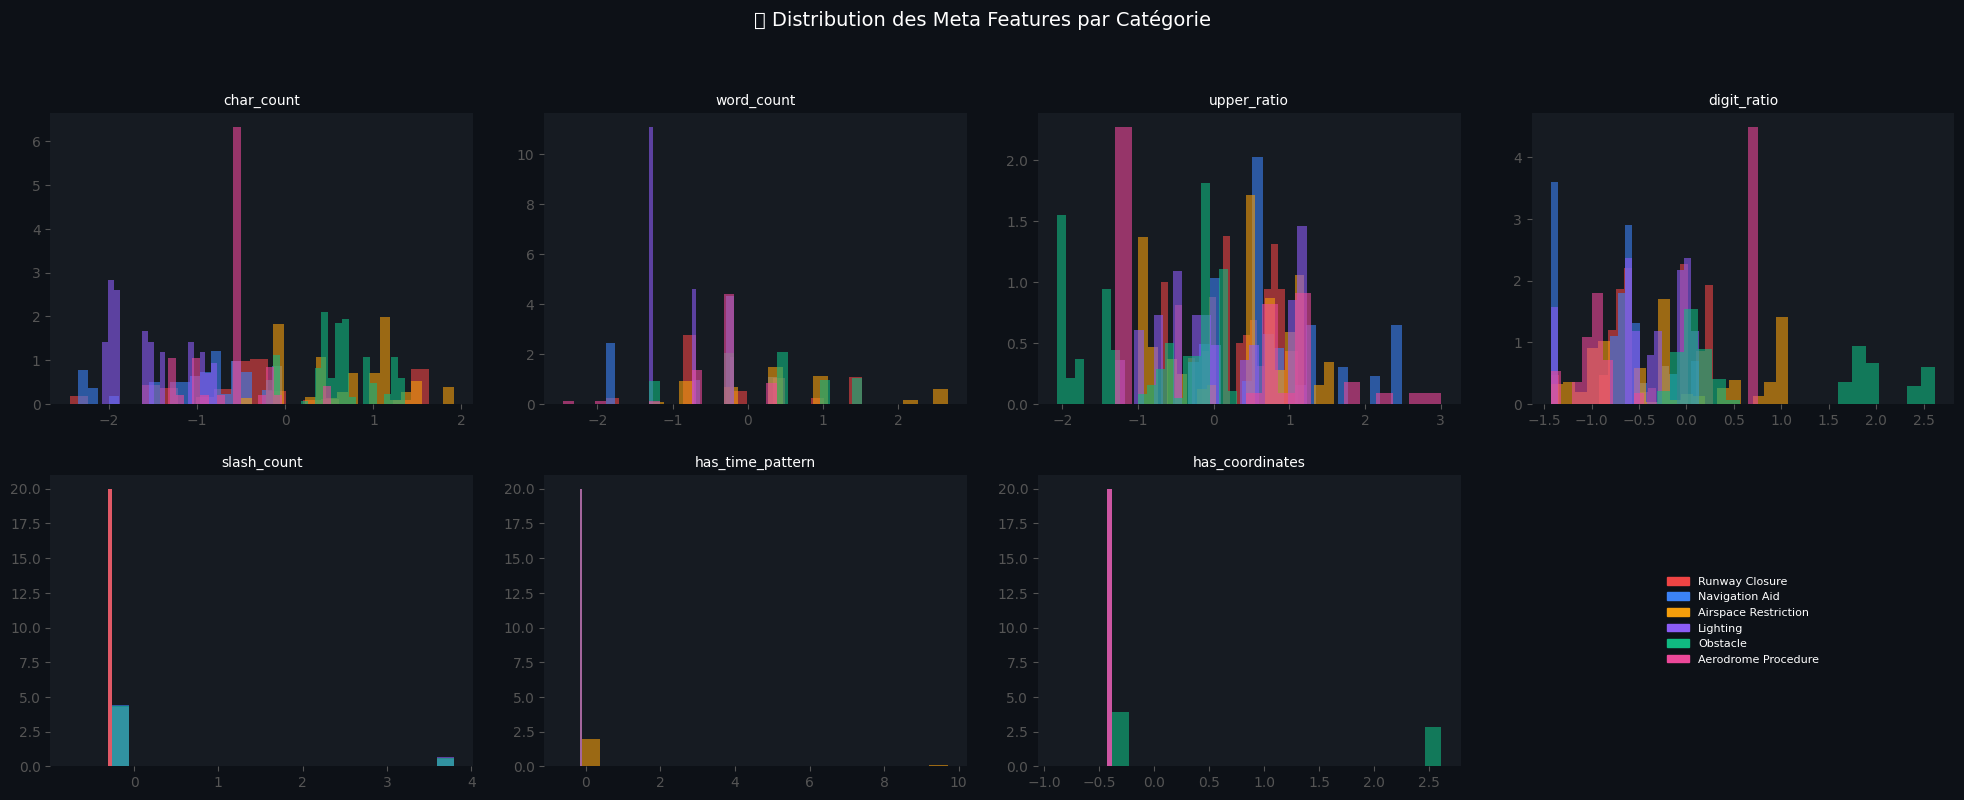

In [5]:
print("=" * 60)
print("  STRATEGY 3 — Meta Features Numériques")
print("=" * 60)

meta = MetaFeatureExtractor()
X_train_meta = meta.fit_transform(X_train)
X_test_meta  = meta.transform(X_test)

print(f"\n📊 Meta features shape : {X_train_meta.shape}")

# Visualisation : heatmap des meta features par catégorie
meta_df = pd.DataFrame(X_train_meta, columns=meta.feature_cols)
meta_df["category"] = y_train.values

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.patch.set_facecolor("#0d1117")

for idx, feat in enumerate(meta.feature_cols):
    ax = axes[idx // 4][idx % 4]
    ax.set_facecolor("#161b22")
    for cat in PALETTE:
        subset = meta_df[meta_df["category"] == cat][feat]
        ax.hist(subset, bins=20, alpha=0.6, color=PALETTE[cat],
                label=cat.replace("_", "\n"), density=True)
    ax.set_title(feat, color="white", fontsize=10)
    ax.spines[:].set_visible(False)
    ax.tick_params(colors="#555")

# Dernière case : légende
ax_legend = axes[1][3]
ax_legend.set_facecolor("#161b22")
ax_legend.axis("off")
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=v, label=k.replace("_"," ").title()) for k,v in PALETTE.items()]
ax_legend.legend(handles=patches, fontsize=8, framealpha=0, labelcolor="white", loc="center")

plt.suptitle("📊 Distribution des Meta Features par Catégorie",
             color="white", fontsize=14, y=1.01)
plt.tight_layout(pad=2)
plt.savefig("../data/processed/fig_07_meta_features.png", dpi=150,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()

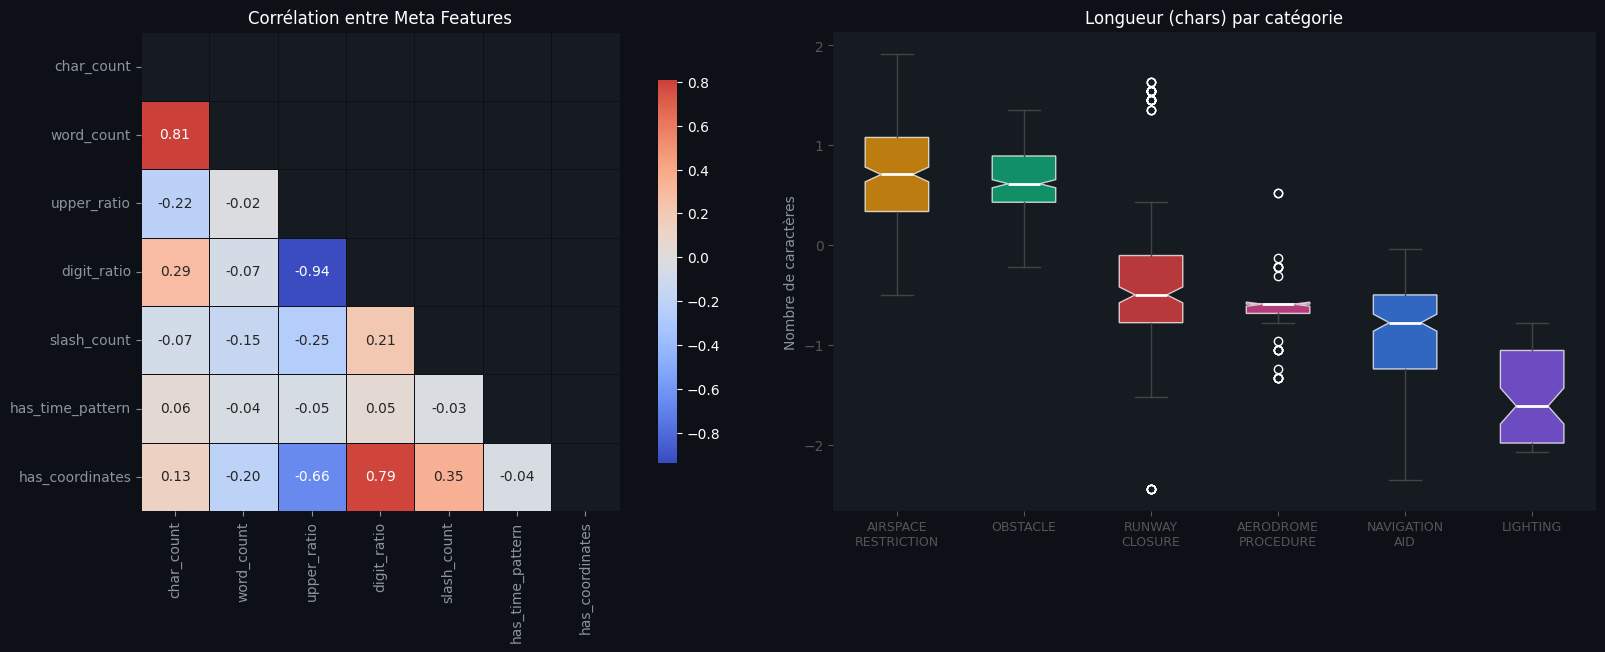


📌 Insight : char_count & word_count corrélés (r≈0.99) → le pipeline
   garde les deux car word_count a un sens sémantique distinct.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#0d1117")

# ── Heatmap corrélation ───────────────────────────────────────────────────────
corr = meta_df[meta.feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], mask=mask, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", square=True,
            linewidths=0.5, linecolor="#0d1117",
            cbar_kws={"shrink": 0.8})
axes[0].set_facecolor("#161b22")
axes[0].set_title("Corrélation entre Meta Features", color="white", fontsize=12)
axes[0].tick_params(colors="#8b949e")

# ── Boxplot char_count par catégorie ─────────────────────────────────────────
order = meta_df.groupby("category")["char_count"].median().sort_values(ascending=False).index
data_bp = [meta_df[meta_df["category"]==c]["char_count"].values for c in order]
bp = axes[1].boxplot(data_bp, patch_artist=True, notch=True,
                     medianprops=dict(color="white", linewidth=2))
for patch, cat in zip(bp["boxes"], order):
    patch.set_facecolor(PALETTE[cat]); patch.set_alpha(0.75)
for el in ["whiskers","caps","fliers"]:
    for item in bp[el]: item.set_color("#444")
axes[1].set_xticklabels([c.replace("_","\n") for c in order], fontsize=9, color="#8b949e")
axes[1].set_facecolor("#161b22")
axes[1].set_title("Longueur (chars) par catégorie", color="white", fontsize=12)
axes[1].set_ylabel("Nombre de caractères", color="#8b949e")
axes[1].spines[:].set_visible(False); axes[1].tick_params(colors="#555")

plt.tight_layout(pad=3)
plt.savefig("../data/processed/fig_08_feature_correlation.png", dpi=150,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()

print("\n📌 Insight : char_count & word_count corrélés (r≈0.99) → le pipeline")
print("   garde les deux car word_count a un sens sémantique distinct.")